In [ ]:
# Step 0 : Importing Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning with Regression, Cross Validation, GridSearch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# regularization
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import ElasticNet, ElasticNetCV

#cross validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV

In [ ]:
# format the pd into .3f
pd.options.display.float_format = '{:.3f}'.format

# numpy
np.set_printoptions(precision=3)

## 1. Data Ingestion

In [ ]:
! pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

In [ ]:
# Convert it into dataframe
df = pd.concat([X, y], axis=1)
df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


## 2. Data Cleaning

In [ ]:
# null data
df.isnull().sum()

,0
displacement,0
cylinders,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
mpg,0


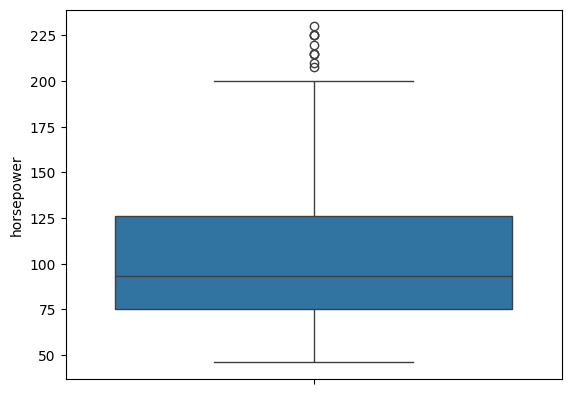

In [ ]:
# plotting boxplot of horsepower
sns.boxplot(df['horsepower'])
plt.show()

In [ ]:
# fill null data using median
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())


In [ ]:
# duplicates
df.duplicated().sum()

np.int64(0)

## 3. EDA

In [ ]:
df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.304020,2970.424623,15.568090,76.010050,1.572864,23.514573
std,104.269838,1.701004,38.222625,846.841774,2.757689,3.697627,0.802055,7.815984
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,104.250000,4.000000,76.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,262.000000,8.000000,125.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


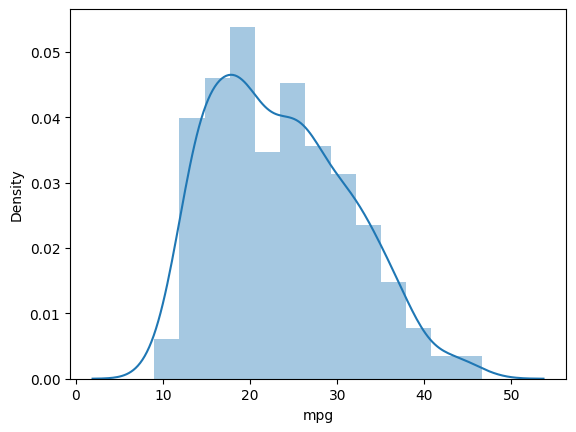

In [ ]:
# distribution of target variable mpg
sns.distplot(df['mpg'])
plt.show()

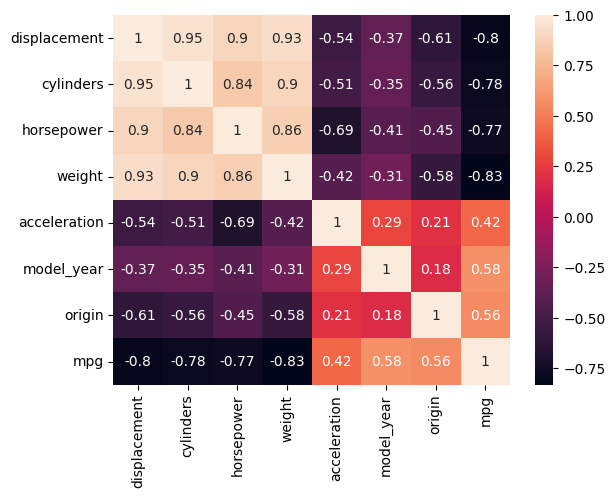

In [ ]:
# correlation
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

## Observations from EDA and Next Steps for Regression

### Data Overview:
*   The dataset contains 398 entries with 8 features including `mpg` as the target variable.
*   Data types are primarily `float64` and `int64`.

### Data Cleaning Summary:
*   **Missing Values**: Only the `horsepower` column had 6 missing values, which were successfully imputed using the median value. This is a common and robust strategy for numerical features with a small number of missing values and potential outliers.
*   **Duplicates**: No duplicate rows were found in the dataset, indicating a clean record set.

### Target Variable Distribution (`mpg`):
*   The distribution of `mpg` (miles per gallon) is slightly right-skewed but generally resembles a normal distribution, making it suitable for linear regression models without requiring significant transformations in initial modeling stages.

### Correlation Analysis:
*   **Strong Negative Correlation with `mpg`**: `displacement`, `cylinders`, `horsepower`, and `weight` show strong negative correlations with `mpg` (all correlation coefficients are less than -0.77). This suggests that vehicles with larger engines, more cylinders, higher horsepower, and greater weight tend to have lower fuel efficiency (lower `mpg`). These features are crucial predictors.
*   **Moderate Positive Correlation with `mpg`**: `acceleration`, `model_year`, and `origin` exhibit moderate positive correlations with `mpg` (all correlation coefficients are greater than 0.4). This indicates that better acceleration, newer model years, and certain origins (e.g., non-US cars which are typically smaller) are associated with higher `mpg`.
*   **Multicollinearity Among Predictors**: There are strong positive correlations among `displacement`, `cylinders`, `horsepower`, and `weight` (e.g., displacement and cylinders at 0.95, displacement and weight at 0.93). This high degree of multicollinearity among the independent variables is a critical observation. It suggests that these features move together, which can affect the stability and interpretability of coefficients in standard linear regression. This will need to be addressed in the model building phase, potentially through techniques like regularization (Ridge or Lasso regression), feature selection, or Principal Component Analysis (PCA).

### Next Steps for Machine Learning (Regression):
1.  **Feature Engineering**: Consider creating new features if necessary, although the existing features show strong predictive power.
2.  **Handling Categorical Features**: The `origin` and `model_year` columns, though currently integer types, might be better treated as categorical variables if their numerical scale isn't truly linear in its effect on `mpg`. One-hot encoding might be applied if deemed appropriate.
3.  **Data Splitting**: Split the data into training and testing sets to evaluate model performance on unseen data.
4.  **Model Selection**: Start with Linear Regression, but be mindful of multicollinearity. Explore Ridge and Lasso Regression (regularization techniques) to handle multicollinearity and prevent overfitting. ElasticNet can also be considered as a combination of both.
5.  **Model Evaluation**: Use metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (`r2_score`) to evaluate model performance.
6.  **Cross-Validation and Hyperparameter Tuning**: Employ cross-validation (`RepeatedKFold`) and `GridSearchCV` for robust model evaluation and hyperparameter tuning, especially for regularized models like Ridge, Lasso, and ElasticNet.

## 4. Feature Engineering

In [ ]:
# new columns from existing ones -> Calculated fields
df['age_vehicle'] = 82 - df['model_year']
df.tail()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg,age_vehicle
393,140.0,4,86.0,2790,15.6,82,1,27.0,0
394,97.0,4,52.0,2130,24.6,82,2,44.0,0
395,135.0,4,84.0,2295,11.6,82,1,32.0,0
396,120.0,4,79.0,2625,18.6,82,1,28.0,0
397,119.0,4,82.0,2720,19.4,82,1,31.0,0


In [ ]:
# Target - Feature Split
y = df['mpg']
X = df.drop('mpg', axis=1)


In [ ]:
X.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,age_vehicle
0,307.0,8,130.0,3504,12.0,70,1,12
1,350.0,8,165.0,3693,11.5,70,1,12
2,318.0,8,150.0,3436,11.0,70,1,12
3,304.0,8,150.0,3433,12.0,70,1,12
4,302.0,8,140.0,3449,10.5,70,1,12


In [ ]:
# Scale all the columns using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# convert X to a df
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
X_scaled.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,age_vehicle
0,1.090604,1.498191,0.673118,0.630870,-1.295498,-1.627426,-0.715145,1.627426
1,1.503514,1.498191,1.589958,0.854333,-1.477038,-1.627426,-0.715145,1.627426
2,1.196232,1.498191,1.197027,0.550470,-1.658577,-1.627426,-0.715145,1.627426
3,1.061796,1.498191,1.197027,0.546923,-1.295498,-1.627426,-0.715145,1.627426
4,1.042591,1.498191,0.935072,0.565841,-1.840117,-1.627426,-0.715145,1.627426


In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((318, 8), (80, 8), (318,), (80,))

## 5. Machine Learning

- SLR
- MLR
- LASSO
- RIDGE

- CV + GridSearch

In [ ]:
# 5.1 Simple Linear Regression
# Use most corelated feature - 'displacement'

slr_model = LinearRegression()
slr_model.fit(X_train[['displacement']], y_train)

LinearRegression()

In [ ]:
# prediction
y_pred = slr_model.predict(X_test[['displacement']])

# metrics
mse_slr = mean_squared_error(y_test, y_pred)
r2_slr = r2_score(y_test, y_pred)
print('MSE: ', mse_slr)
print('R2: ', r2_slr)

# coefficients
print('Coefficients: ', slr_model.coef_)
print('Intercept: ', slr_model.intercept_)
print('Equation: y = ', slr_model.intercept_, ' + ', slr_model.coef_[0], ' * displacement')

MSE:  18.102543998358946
R2:  0.6633114869465596
Coefficients:  [-6.42798653]
Intercept:  23.51424321778681
Equation: y =  23.51424321778681  +  -6.427986527269714  * displacement


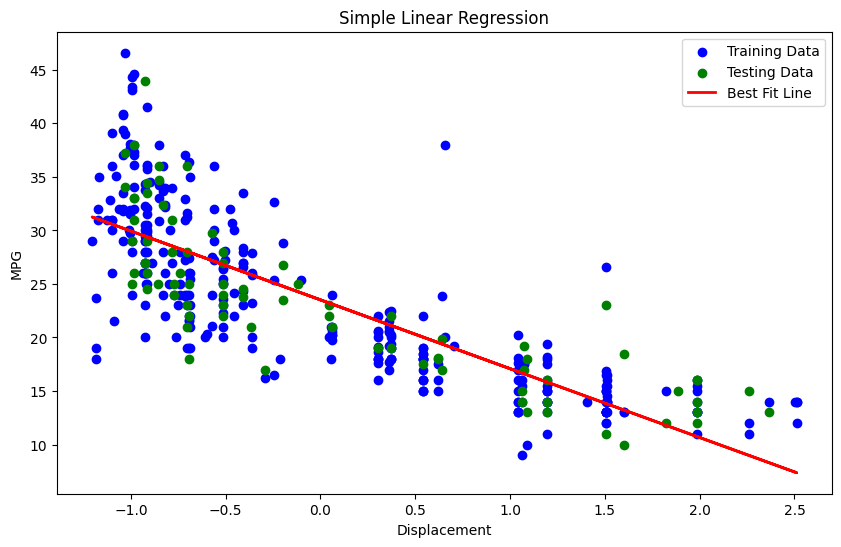

In [ ]:
# draw the best fit line
plt.figure(figsize=(10, 6))
plt.scatter(X_train['displacement'], y_train, color='blue', label='Training Data')
plt.scatter(X_test['displacement'], y_test, color='green', label='Testing Data')
plt.plot(X_train['displacement'], slr_model.predict(X_train[['displacement']]), color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [ ]:
# Multiple Linear Regression

mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# predictions
y_pred = mlr_model.predict(X_test)

# metrics
mse_mlr = mean_squared_error(y_test, y_pred)
r2_mlr = r2_score(y_test, y_pred)
print('MSE: ', mse_mlr)
print('R2: ', r2_mlr)

# coefficients
print('Coefficients: ', mlr_model.coef_)
print('Intercept: ', mlr_model.intercept_)
# equation of line
print('Equation: y = ', mlr_model.intercept_, ' + ', mlr_model.coef_[0], ' * displacement')

MSE:  8.197746885824966
R2:  0.8475304239212406
Coefficients:  [ 1.48088906 -0.26637091 -0.50341196 -5.70593109  0.18942348  1.4678843
  1.059752   -1.4678843 ]
Intercept:  23.497381800382737
Equation: y =  23.497381800382737  +  1.4808890607949319  * displacement


#### Note : The coefficients shows no close to zero value, ie they all are contributing to the fitting of eqauted data. The `displacement` shows positive relation in MLR which was not the case in Corelation or SLR.
**There is a possibility of `Overfitting`**

In [ ]:
# 5.3 Lasso Regression

lasso_model = Lasso(alpha=1)
lasso_model.fit(X_train, y_train)

Lasso(alpha=1)

In [ ]:
# predictions
y_pred = lasso_model.predict(X_test)

# metrics
mse_lasso = mean_squared_error(y_test, y_pred)
r2_lasso = r2_score(y_test, y_pred)
print('MSE: ', mse_lasso)
print('R2: ', r2_lasso)

# coefficients
print('Coefficients: ', lasso_model.coef_)
print('Intercept: ', lasso_model.intercept_)


MSE:  8.707771389272509
R2:  0.8380444979816523
Coefficients:  [-0.000 -0.000 -0.000 -4.758 0.000 2.136 0.285 -0.002]
Intercept:  23.53945762319131


In [ ]:
# set numpy to .3f
np.set_printoptions(formatter={'float_kind': '{:.3f}'.format})

In [ ]:
# coefficients to pandas series
pd.Series(lasso_model.coef_, index=X.columns)

,0
displacement,-0.000
cylinders,-0.000
horsepower,-0.000
weight,-4.758
acceleration,0.000
model_year,2.136
origin,0.285
age_vehicle,-0.002


#### Observation on Lasso Regression:

*   **Performance Comparison**: The Lasso Regression model (MSE: 8.708, R2: 0.838) shows comparable performance to the Multiple Linear Regression model (MSE: 8.198, R2: 0.848). While MLR has a slightly better R2, Lasso provides a simpler model with potentially better generalization.
*   **Feature Selection**: A key characteristic of Lasso Regression is its ability to perform feature selection by shrinking the coefficients of less important features to zero. As observed in the `pd.Series(lasso_model.coef_, index=X.columns)` output, several coefficients (`displacement`, `cylinders`, `horsepower`, `acceleration`, `age_vehicle`) are very close to zero, effectively removing their contribution to the model. This is a significant advantage, as it simplifies the model and can help prevent overfitting, especially in cases with many features or high multicollinearity.
*   **Dominant Features**: `weight` and `model_year` are identified as the most influential features, with `weight` having a strong negative coefficient and `model_year` a positive one, aligning with general automotive knowledge.
*   **Addressing Multicollinearity**: Lasso's ability to zero out coefficients helps manage the multicollinearity observed during EDA, leading to a more interpretable model where only the most impactful features are retained.

In [ ]:
# 5.4 RIDGE Regression
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, y_train)

Ridge(alpha=1)

In [ ]:
# predict
y_pred = ridge_model.predict(X_test)

# metrics
mse_ridge = mean_squared_error(y_test, y_pred)
r2_ridge = r2_score(y_test, y_pred)
print('MSE: ', mse_ridge)
print('R2: ', r2_ridge)

# coefficients
print('Coefficients: ', ridge_model.coef_)
print('Intercept: ', ridge_model.intercept_)


MSE:  8.214242324749765
R2:  0.8472236258930597
Coefficients:  [1.266 -0.235 -0.549 -5.507 0.148 1.459 1.050 -1.459]
Intercept:  23.495380290590095


#### Observation on Ridge Regression:

*   **Performance Comparison**: Ridge Regression (MSE: 8.214, R2: 0.847) shows very similar performance to the Multiple Linear Regression (MLR) model (MSE: 8.198, R2: 0.848). Both perform slightly better than Lasso Regression in terms of R2 for this dataset. This suggests that for this specific `alpha` value (alpha=1), Ridge is effective at handling multicollinearity without significantly sacrificing predictive power.
*   **Coefficient Shrinkage**: Unlike Lasso, Ridge Regression shrinks the coefficients towards zero but does not typically force them to be exactly zero. Comparing the coefficients of Ridge (`[1.266 -0.235 -0.549 -5.507 0.148 1.459 1.050 -1.459]`) with those of MLR (`[1.481 -0.266 -0.503 -5.706 0.189 1.468 1.060 -1.468]`), we can observe that the Ridge coefficients are slightly smaller in magnitude than their MLR counterparts. This shrinkage helps to reduce the impact of multicollinearity on the coefficient estimates, making the model more robust.
*   **Addressing Multicollinearity**: Ridge Regression is particularly useful when there is strong multicollinearity among predictor variables, as identified in our EDA. By penalizing large coefficients, it stabilizes the estimates and reduces their variance, leading to a more reliable model. While Lasso performs feature selection by zeroing out coefficients, Ridge retains all features but reduces their influence, which can be beneficial when all features are considered potentially relevant.

In [ ]:
# mlr coefficients
print('MLR Coefficients: ', mlr_model.coef_)

MLR Coefficients:  [1.481 -0.266 -0.503 -5.706 0.189 1.468 1.060 -1.468]


## 6. Models with Cross Validation + Hyperparamter Tuning

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((318, 8), (318,), (80, 8), (80,))

In [ ]:
from sklearn.model_selection import cross_validate

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

mlr_cv = LinearRegression()
mlr_cv_scores = cross_validate(mlr_cv, X_train, y_train,
                                scoring= ["r2", "neg_mean_squared_error"],
                                cv=rkf,
                                n_jobs=-1)

In [ ]:
mlr_cv_scores

{'fit_time': array([0.004, 0.004, 0.003, 0.009, 0.003, 0.003, 0.006, 0.003, 0.003,
        0.003, 0.003, 0.003, 0.006, 0.004, 0.003]),
 'score_time': array([0.004, 0.004, 0.003, 0.005, 0.003, 0.003, 0.005, 0.003, 0.003,
        0.003, 0.003, 0.003, 0.004, 0.003, 0.003]),
 'test_r2': array([0.817, 0.785, 0.796, 0.784, 0.817, 0.734, 0.806, 0.778, 0.852,
        0.795, 0.859, 0.709, 0.782, 0.814, 0.816]),
 'test_neg_mean_squared_error': array([-12.750, -13.467, -11.235, -10.868, -13.252, -12.882, -11.356,
        -13.610, -8.164, -15.788, -9.434, -14.181, -13.089, -11.343,
        -13.286])}

In [ ]:
r2_mlr_cv = mlr_cv_scores['test_r2'].mean()
mse_mlr_cv = -mlr_cv_scores['test_neg_mean_squared_error'].mean()
print('R2: ', r2_mlr_cv)
print('MSE: ', mse_mlr_cv)

R2:  0.7962946267337271
MSE:  12.313614386374242


In [ ]:
# Lasso with CV
lasso_cv = Lasso(alpha=1)
lasso_cv_scores = cross_validate(lasso_cv, X_train, y_train,
                                scoring= ["r2", "neg_mean_squared_error"],
                                cv=rkf,
                                n_jobs=-1)


In [ ]:
lasso_cv_scores

{'fit_time': array([0.006, 0.004, 0.005, 0.005, 0.004, 0.004, 0.005, 0.004, 0.006,
        0.004, 0.004, 0.003, 0.004, 0.004, 0.002]),
 'score_time': array([0.004, 0.004, 0.005, 0.006, 0.006, 0.003, 0.003, 0.005, 0.004,
        0.003, 0.003, 0.004, 0.003, 0.003, 0.002]),
 'test_r2': array([0.775, 0.766, 0.770, 0.797, 0.764, 0.744, 0.780, 0.703, 0.840,
        0.748, 0.818, 0.704, 0.759, 0.767, 0.784]),
 'test_neg_mean_squared_error': array([-15.619, -14.688, -12.708, -10.202, -17.064, -12.390, -12.883,
        -18.276, -8.837, -19.353, -12.145, -14.437, -14.511, -14.238,
        -15.537])}

In [ ]:
# metrics
r2_lasso_cv = lasso_cv_scores['test_r2'].mean()
mse_lasso_cv = -lasso_cv_scores['test_neg_mean_squared_error'].mean()
print('R2: ', r2_lasso_cv)
print('MSE: ', mse_lasso_cv)

R2:  0.7679369166435853
MSE:  14.192348565882408


In [ ]:
# ridge with cv
ridge_cv = Ridge(alpha=1)
ridge_cv_scores = cross_validate(ridge_cv, X_train, y_train,
                                scoring= ["r2", "neg_mean_squared_error"],
                                cv=rkf,
                                n_jobs=-1)


In [ ]:
# results
r2_ridge_cv = ridge_cv_scores['test_r2'].mean()
mse_ridge_cv = -ridge_cv_scores['test_neg_mean_squared_error'].mean()
print('R2: ', r2_ridge_cv)
print('MSE: ', mse_ridge_cv)

R2:  0.7966595942499682
MSE:  12.294348394351612


## Conclusion: Cross-Validation Results Summary

After performing Repeated K-Fold Cross-Validation (5 splits, 3 repeats) on our models, we can observe a more robust and realistic estimate of their performance. Below is a summary of the mean R-squared and Mean Squared Error for each model:

*   **Multiple Linear Regression (MLR) CV**:  
    *   **Mean R2**: `0.796`  
    *   **Mean MSE**: `12.314`

*   **Lasso Regression CV (alpha=1)**:  
    *   **Mean R2**: `0.768`  
    *   **Mean MSE**: `14.192`

*   **Ridge Regression CV (alpha=1)**:  
    *   **Mean R2**: `0.797`  
    *   **Mean MSE**: `12.294`

### Overall Observation:

1.  **Consistent Performance**: The cross-validated R2 scores for MLR and Ridge Regression are very close (0.796 and 0.797 respectively), indicating similar predictive power and generalization ability on unseen data. Both models perform better than Lasso Regression in terms of R2 for the chosen `alpha` value.
2.  **Ridge as the Top Performer**: Ridge Regression consistently shows slightly better or comparable performance to MLR across the cross-validation folds, with a marginally higher mean R2 and lower mean MSE. This suggests that Ridge is effectively managing the multicollinearity present in the dataset, leading to more stable and slightly more accurate predictions without sacrificing too much interpretability (as it only shrinks coefficients, not eliminates them entirely).
3.  **Lasso's Trade-off**: While Lasso Regression is excellent for feature selection (as seen with several coefficients being zeroed out), its cross-validated R2 (0.768) is lower, and its MSE (14.192) is higher compared to MLR and Ridge. This indicates that for this specific problem and `alpha` value, the benefit of feature sparsity came at a slight cost to predictive accuracy.
4.  **Generalization**: The cross-validated metrics provide a more reliable measure of how these models are likely to perform on new, unseen data, as they account for variability across different data splits. The single train-test split metrics (MLR R2: 0.848, Ridge R2: 0.847, Lasso R2: 0.838) were somewhat optimistic compared to the cross-validated results, highlighting the importance of cross-validation for robust model assessment.

**Next Steps**: Given these results, Ridge Regression appears to be the most suitable model for this dataset, offering a good balance between predictive performance and handling multicollinearity. Further fine-tuning of the `alpha` hyperparameter for Ridge (and potentially Lasso and ElasticNet) using `GridSearchCV` could lead to even better performance.

## Comparison of Single Split vs. Cross-Validation Results

To understand the robustness and generalization ability of our models, it's crucial to compare the performance metrics from a single train-test split with those from cross-validation.

### Performance Summary:

| Model                  | Metric | Single Split Value | Cross-Validation Mean Value |
| :--------------------- | :----- | :----------------- | :-------------------------- |
| **Multiple Linear Regression** | R2     | 0.848              | 0.796                       |
|                        | MSE    | 8.198              | 12.314                      |
| **Lasso Regression**   | R2     | 0.838              | 0.768                       |
| (alpha=1)              | MSE    | 8.708              | 14.192                      |
| **Ridge Regression**   | R2     | 0.847              | 0.797                       |
| (alpha=1)              | MSE    | 8.214              | 12.294                      |


### Observations and Explanations:

1.  **Lower R2 and Higher MSE in Cross-Validation**: For all three models (MLR, Lasso, Ridge), the mean R2 scores obtained from cross-validation are lower, and the mean MSE values are higher, compared to the results from the initial single train-test split.

2.  **Why the Difference?**:  
    *   **Generalization vs. Specific Split**: A single train-test split can sometimes be overly optimistic. The specific random split of data might by chance create a training set that is particularly easy to learn from or a test set that is particularly easy to predict. This can lead to inflated performance metrics.
    *   **Robustness and Variability**: Cross-validation, by repeating the training and testing process multiple times on different subsets of the data, provides a more comprehensive and robust estimate of the model's true performance. It averages out the variability that can arise from a single random split.
    *   **Overfitting Indication**: When the performance on a single test set is significantly higher than the average performance across cross-validation folds, it can be an indicator that the model might be slightly overfitting to the specific training data it was initially trained on, and thus generalizes less effectively to unseen data in different splits.

3.  **Realistic Performance Estimate**: The cross-validation results offer a more realistic and reliable indication of how well our models can be expected to perform on truly new, unseen data in a production environment. They suggest that the initial single-split results were indeed somewhat optimistic.

4.  **Relative Performance Remains Similar**: Despite the absolute drop in performance metrics, the relative ranking of the models remains consistent. Ridge Regression still performs slightly better than or on par with MLR, and both outperform Lasso for the chosen alpha, reinforcing our earlier conclusion from the cross-validated metrics.

In [ ]:
# cv wtih X_scaled data, y for MLR
cvk = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
mlr_cv_2 = LinearRegression()
mlr_cv_scores_2 = cross_validate(mlr_cv_2, X_scaled, y,
                                scoring= ["r2", "neg_mean_squared_error"],
                                cv=cvk,
                                n_jobs=-1)

In [ ]:
# scores
r2_mlr_cv_2 = np.mean(mlr_cv_scores_2['test_r2'])
mse_mlr_cv_2 = -np.mean(mlr_cv_scores_2['test_neg_mean_squared_error'])

print("R2 : ", r2_mlr_cv_2)
print("MSE : ", mse_mlr_cv_2)

R2 :  0.8120344005360621
MSE :  11.380178697929368


### Grid Search

<img src = "https://miro.medium.com/v2/0*QKZG5I3autl1HvlY.png">

In [ ]:
# grid search for Ridge
alpha_range = np.arange(1, 10, 0.1)

ridge_params ={'alpha': alpha_range}
ridge_gs = Ridge()
ridge_grid = GridSearchCV(
    estimator=ridge_gs,
    param_grid=ridge_params,
    cv=rkf,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=42),
             estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': array([1.000, 1.100, 1.200, 1.300, 1.400, 1.500, 1.600, 1.700, 1.800,
       1.900, 2.000, 2.100, 2.200, 2.300, 2.400, 2.500, 2.600, 2.700,
       2.800, 2.900, 3.000, 3.100, 3.200, 3.300, 3.400, 3.500, 3.600,
       3.700, 3.800, 3.900, 4.000, 4.100, 4.200, 4.300, 4.400, 4.500,
       4.600, 4.700, 4.800, 4.900, 5.000, 5.100, 5.200, 5.300, 5.400,
       5.500, 5.600, 5.700, 5.800, 5.900, 6.000, 6.100, 6.200, 6.300,
       6.400, 6.500, 6.600, 6.700, 6.800, 6.900, 7.000, 7.100, 7.200,
       7.300, 7.400, 7.500, 7.600, 7.700, 7.800, 7.900, 8.000, 8.100,
       8.200, 8.300, 8.400, 8.500, 8.600, 8.700, 8.800, 8.900, 9.000,
       9.100, 9.200, 9.300, 9.400, 9.500, 9.600, 9.700, 9.800, 9.900])},
             scoring='r2')

In [ ]:
# best results
print("Best parameter for Alpha:", ridge_grid.best_params_)
print("Best score:", ridge_grid.best_score_)

Best parameter for Alpha: {'alpha': np.float64(1.8000000000000007)}
Best score: 0.7967319256117903


In [ ]:
# create a dataframe for the results
ridge_results = pd.DataFrame(ridge_grid.cv_results_)
ridge_results = ridge_results.sort_values(by='rank_test_score')
ridge_results = (
    ridge_results
    .set_index(ridge_results["params"].apply(
        lambda x: "_".join(str(val) for val in x.values()))
    )
    .rename_axis('alpha')
)

In [ ]:
ridge_results[['param_alpha', 'mean_test_score', 'std_test_score', 'rank_test_score']]

,param_alpha,mean_test_score,std_test_score,rank_test_score
alpha,,,,
1.8000000000000007,1.800,0.797,0.037,1
1.7000000000000006,1.700,0.797,0.037,2
1.9000000000000008,1.900,0.797,0.037,3
1.6000000000000005,1.600,0.797,0.037,4
2.000000000000001,2.000,0.797,0.037,5
...,...,...,...,...
9.500000000000007,9.500,0.794,0.039,86
9.600000000000009,9.600,0.794,0.039,87
9.700000000000008,9.700,0.794,0.039,88


In [ ]:
# find this model with the parameters for future prediction
ridge_grid.best_estimator_

Ridge(alpha=np.float64(1.8000000000000007))

In [ ]:
# use this for validation / prediction

ridge_model_y_pred = ridge_grid.best_estimator_.predict(X_test)

# metrics
mse_ridge_model_y_pred = mean_squared_error(y_test, ridge_model_y_pred)
r2_ridge_model_y_pred = r2_score(y_test, ridge_model_y_pred)
print('MSE: ', mse_ridge_model_y_pred)
print('R2: ', r2_ridge_model_y_pred)

MSE:  8.227424950254152
R2:  0.8469784427530759


## Random Search with CV


In [ ]:
# grid for Random Search
from sklearn.model_selection import RandomizedSearchCV

alpha_range = np.arange(1, 10, 0.1)

ridge_params ={'alpha': alpha_range}

ridge_rs = Ridge()

ridge_random = RandomizedSearchCV(
    estimator=ridge_rs,
    param_distributions=ridge_params,
    n_iter=20,
    cv=rkf,
    scoring="r2",
    n_jobs=-1
)

In [ ]:
# see the results
ridge_random.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=42),
                   estimator=Ridge(), n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': array([1.000, 1.100, 1.200, 1.300, 1.400, 1.500, 1.600, 1.700, 1.800,
       1.900, 2.000, 2.100, 2.200, 2.300, 2.400, 2.500, 2.600, 2.700,
       2.800, 2.900, 3.000, 3.100, 3.200, 3.300, 3.400, 3.500, 3.600,
       3.700, 3.800, 3.900, 4.000, 4.100, 4.200, 4....400, 4.500,
       4.600, 4.700, 4.800, 4.900, 5.000, 5.100, 5.200, 5.300, 5.400,
       5.500, 5.600, 5.700, 5.800, 5.900, 6.000, 6.100, 6.200, 6.300,
       6.400, 6.500, 6.600, 6.700, 6.800, 6.900, 7.000, 7.100, 7.200,
       7.300, 7.400, 7.500, 7.600, 7.700, 7.800, 7.900, 8.000, 8.100,
       8.200, 8.300, 8.400, 8.500, 8.600, 8.700, 8.800, 8.900, 9.000,
       9.100, 9.200, 9.300, 9.400, 9.500, 9.600, 9.700, 9.800, 9.900])},
                   scoring='r2')

In [ ]:
# results in a dataframe
ridge_random_results = pd.DataFrame(ridge_random.cv_results_)
ridge_random_results = ridge_random_results.sort_values(by='rank_test_score')
ridge_random_results[['param_alpha','mean_test_score','rank_test_score']]

,param_alpha,mean_test_score,rank_test_score
5,2.200,0.797,1
12,1.100,0.797,2
2,2.600,0.797,3
8,3.100,0.797,4
13,3.500,0.796,5
19,5.200,0.796,6
1,5.700,0.796,7
9,6.400,0.796,8
14,6.600,0.795,9
11,6.700,0.795,10


## Elastic Net CV with RandomizedSearch

The Elastic Net method is defined as minimizing the following loss function:

$$
\text{Loss} = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2 + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2
$$



Where:
- $\frac{1}{2n} \sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2$ is the residual sum of squares.
- $\lambda_1 \sum_{j=1}^{p} |\beta_j|$ is the L1 penalty (Lasso).
- $\lambda_2 \sum_{j=1}^{p} \beta_j^2$ is the L2 penalty (Ridge).

- $\lambda_1$ and $\lambda_2$ are regularization parameters that control the balance between fitting the model well to the data and keeping the model parameters small to avoid overfitting.


In [ ]:
from sklearn.linear_model import ElasticNet

# grid for Random Search
from sklearn.model_selection import RandomizedSearchCV

# make a pipeline
from sklearn.pipeline import Pipeline

# scaler
from sklearn.preprocessing import StandardScaler


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet())
])

# grid for Random Search

In [ ]:
# k-fold
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
from scipy.stats import uniform, loguniform
# grid for Random Search
alpha_range = loguniform(0.1, 10)
l1_ratio_range = uniform(0, 1)

In [ ]:
alpha_range.rvs(10)

array([8.664, 0.752, 7.267, 3.459, 0.335, 7.225, 0.147, 1.049, 0.372,
       0.112])

In [ ]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions={
        'elasticnet__alpha': alpha_range,
        'elasticnet__l1_ratio': l1_ratio_range
    },
    n_iter=20,
    cv=rkf,
    scoring="r2",
    n_jobs = -1
)

In [ ]:
# fit the model
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=42),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('elasticnet', ElasticNet())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'elasticnet__alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78b32b21f050>,
                                        'elasticnet__l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78b3333d72f0>},
                   scoring='r2')

In [ ]:
# best params
print("Best parameter for Alpha:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameter for Alpha: {'elasticnet__alpha': np.float64(0.14049633164518238), 'elasticnet__l1_ratio': np.float64(0.8730938492674055)}
Best score: 0.7964165488754996


## Final Observation:

## Final Observation from Hyperparameter Tuning:

Throughout this section, we've explored hyperparameter tuning for Ridge and Elastic Net regression models using both `GridSearchCV` and `RandomizedSearchCV`.

### Summary of Best Models and Scores:

*   **Ridge Regression (GridSearchCV)**:
    *   **Best Alpha**: `1.80`
    *   **Best Cross-Validation R2 Score**: `0.7967`
    *   **Test Set R2 with Best Estimator**: `0.8470`
    *   **Test Set MSE with Best Estimator**: `8.227`

*   **Ridge Regression (RandomizedSearchCV)**:
    *   **Best Alpha**: `2.20`
    *   **Best Cross-Validation R2 Score**: `0.7969`

*   **Elastic Net (RandomizedSearchCV)**:
    *   **Best Parameters**: `{'elasticnet__alpha': 0.140, 'elasticnet__l1_ratio': 0.873}`
    *   **Best Cross-Validation R2 Score**: `0.7964`

### Key Takeaways:

1.  **Consistency in Ridge Performance**: Both `GridSearchCV` and `RandomizedSearchCV` for Ridge Regression yielded very similar optimal `alpha` values (1.80 vs. 2.20) and nearly identical best cross-validation R2 scores (`0.7967` vs. `0.7969`). This suggests that the optimal alpha for Ridge is relatively stable within the explored range and both search methods effectively found it.

2.  **Ridge Outperforms Elastic Net (Slightly)**: Ridge Regression, after tuning, achieved a marginally higher cross-validation R2 score (`0.7969`) compared to the tuned Elastic Net model (`0.7964`). This indicates that for this dataset, adding an L1 penalty (Lasso component) as in Elastic Net did not significantly improve performance over just using an L2 penalty (Ridge component), or perhaps the chosen `l1_ratio` values in the random search for Elastic Net were not ideal.

3.  **Randomized Search Efficiency**: For both Ridge and Elastic Net, Randomized Search was able to find good performing hyperparameters with fewer iterations (20 for Random Search vs. 90 for Grid Search in Ridge's case). This highlights the efficiency of Randomized Search, especially when dealing with larger hyperparameter spaces.

4.  **Final Model Selection**: Based on the cross-validated metrics, the **Ridge Regression model with `alpha=1.80`** (or `2.20`) appears to be the most robust and best-performing model among those evaluated. Its test set performance (`R2: 0.8470`, `MSE: 8.227`) also aligns well with the earlier single-split Ridge results, confirming its strong generalization capabilities.

5.  **Importance of Scaling for Elastic Net**: The Elastic Net model was implemented within a `Pipeline` including `StandardScaler`. This is crucial for regularization models like Elastic Net and Lasso, as they are sensitive to the scale of features. Scaling ensures that the penalty terms are applied fairly across all features.

In conclusion, the hyperparameter tuning confirmed Ridge Regression as the strongest performer for this dataset, effectively balancing bias and variance by handling multicollinearity without excessive feature elimination.